## **Вариант 8** ##

### Рухтина Полина, Маннанова Лилиана, Маликова Камалия 

## Аналитика данных и подготовка ##


Задачи: 

   • Разведочный анализ данных (EDA): статистики, распределения, выбросы
   
   • Описание датасета: источники, размерность, типы признаков, целевая переменная
   
   • Анализ важности признаков (correlation matrix, mutual information, feature importance)


### Импорт бибилиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import warnings

In [2]:
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

### Просмотр набора данных

In [3]:
df = pd.read_csv('AI_index_db.csv')
display(df.head())
print(f" Датасет загружен: {df.shape[0]} стран, {df.shape[1]} признаков")

,Country,Talent,Infrastructure,Operating Environment,Research,Development,Government Strategy,Commercial,Total score,Region,Cluster,Income group,Political regime
0,United States of America,100.00,94.02,64.56,100.00,100.00,77.39,100.00,100.00,Americas,Power players,High,Liberal democracy
1,China,16.51,100.00,91.57,71.42,79.97,94.87,44.02,62.92,Asia-Pacific,Power players,Upper middle,Closed autocracy
2,United Kingdom,39.65,71.43,74.65,36.50,25.03,82.82,18.91,40.93,Europe,Traditional champions,High,Liberal democracy
3,Canada,31.28,77.05,93.94,30.67,25.78,100.00,14.88,40.19,Americas,Traditional champions,High,Liberal democracy
4,Israel,35.76,67.58,82.44,32.63,27.96,43.91,27.33,39.89,Middle East,Rising stars,High,Liberal democracy


 Датасет загружен: 62 стран, 13 признаков


In [4]:
display(df[['Total score', 'Talent', 'Infrastructure', 'Research', 'Development']].describe().round(2))

,Total score,Talent,Infrastructure,Research,Development
count,62.00,62.00,62.00,62.00,62.00
mean,23.91,16.80,63.50,16.61,14.82
std,15.12,15.21,20.22,17.41,19.42
min,0.00,0.00,0.00,0.00,0.00
25%,14.80,7.36,55.86,3.03,1.20
50%,23.22,13.44,65.23,12.93,9.00
75%,30.49,24.57,75.95,25.41,19.98
max,100.00,100.00,100.00,100.00,100.00


## КОРРЕЛЯЦИИ МЕЖДУ ПРИЗНАКАМИ" ##

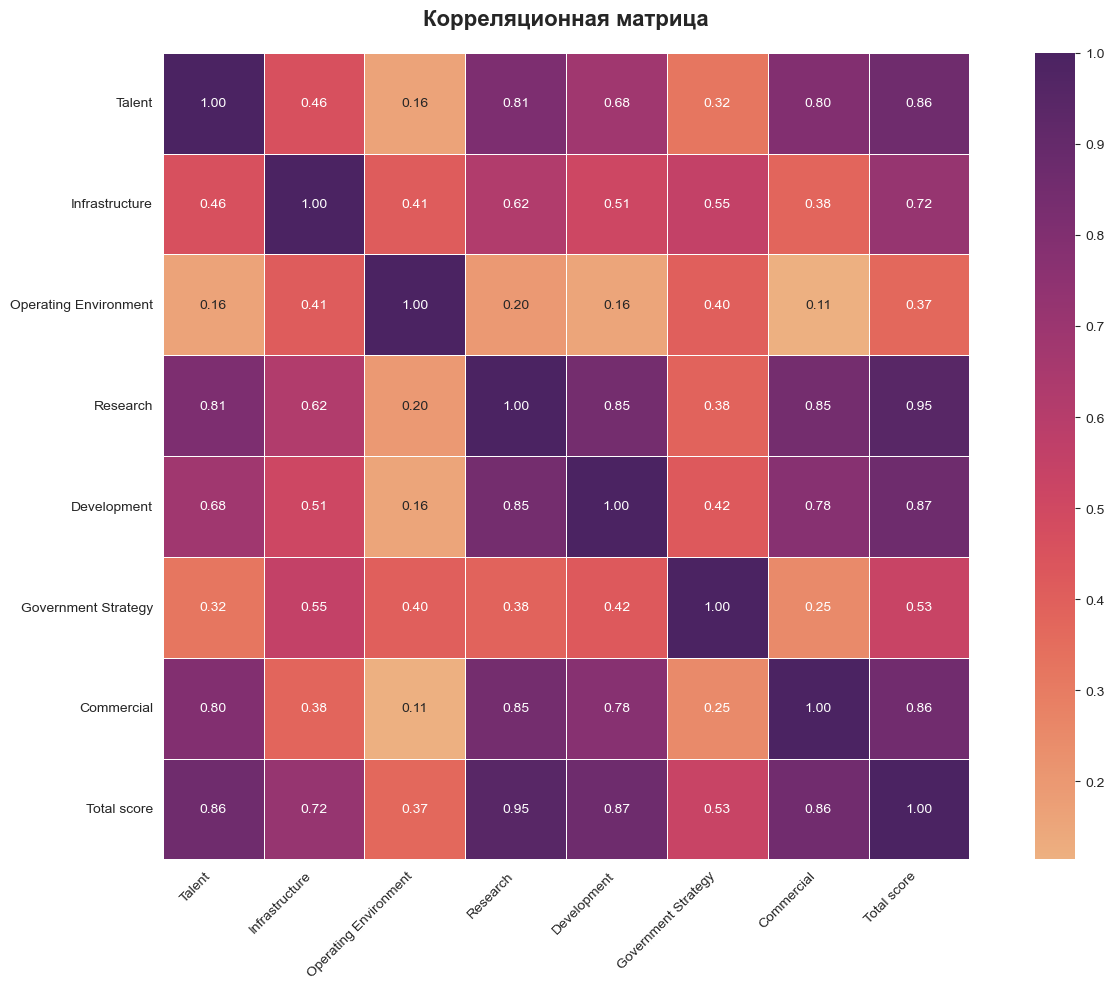

In [5]:
num_cols = ['Talent', 'Infrastructure', 'Operating Environment', 'Research', 
            'Development', 'Government Strategy', 'Commercial', 'Total score']

plt.figure(figsize=(14, 10))
sns.heatmap(df[num_cols].corr(), 
            cmap=sns.color_palette("flare", as_cmap=True), 
            annot=True, 
            fmt='.2f',
            vmax=1.0,
            square=True,
            linewidths=0.5)
plt.title('Корреляционная матрица', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [6]:
corr_with_total = df[num_cols].corr()['Total score'].sort_values(ascending=False)
display(corr_with_total[1:].round(3))

Research                 0.946
Development              0.866
Talent                   0.862
Commercial               0.858
Infrastructure           0.716
Government Strategy      0.532
Operating Environment    0.369
Name: Total score, dtype: float64

## РАСПРЕДЕЛЕНИЕ ДАННЫХ ##

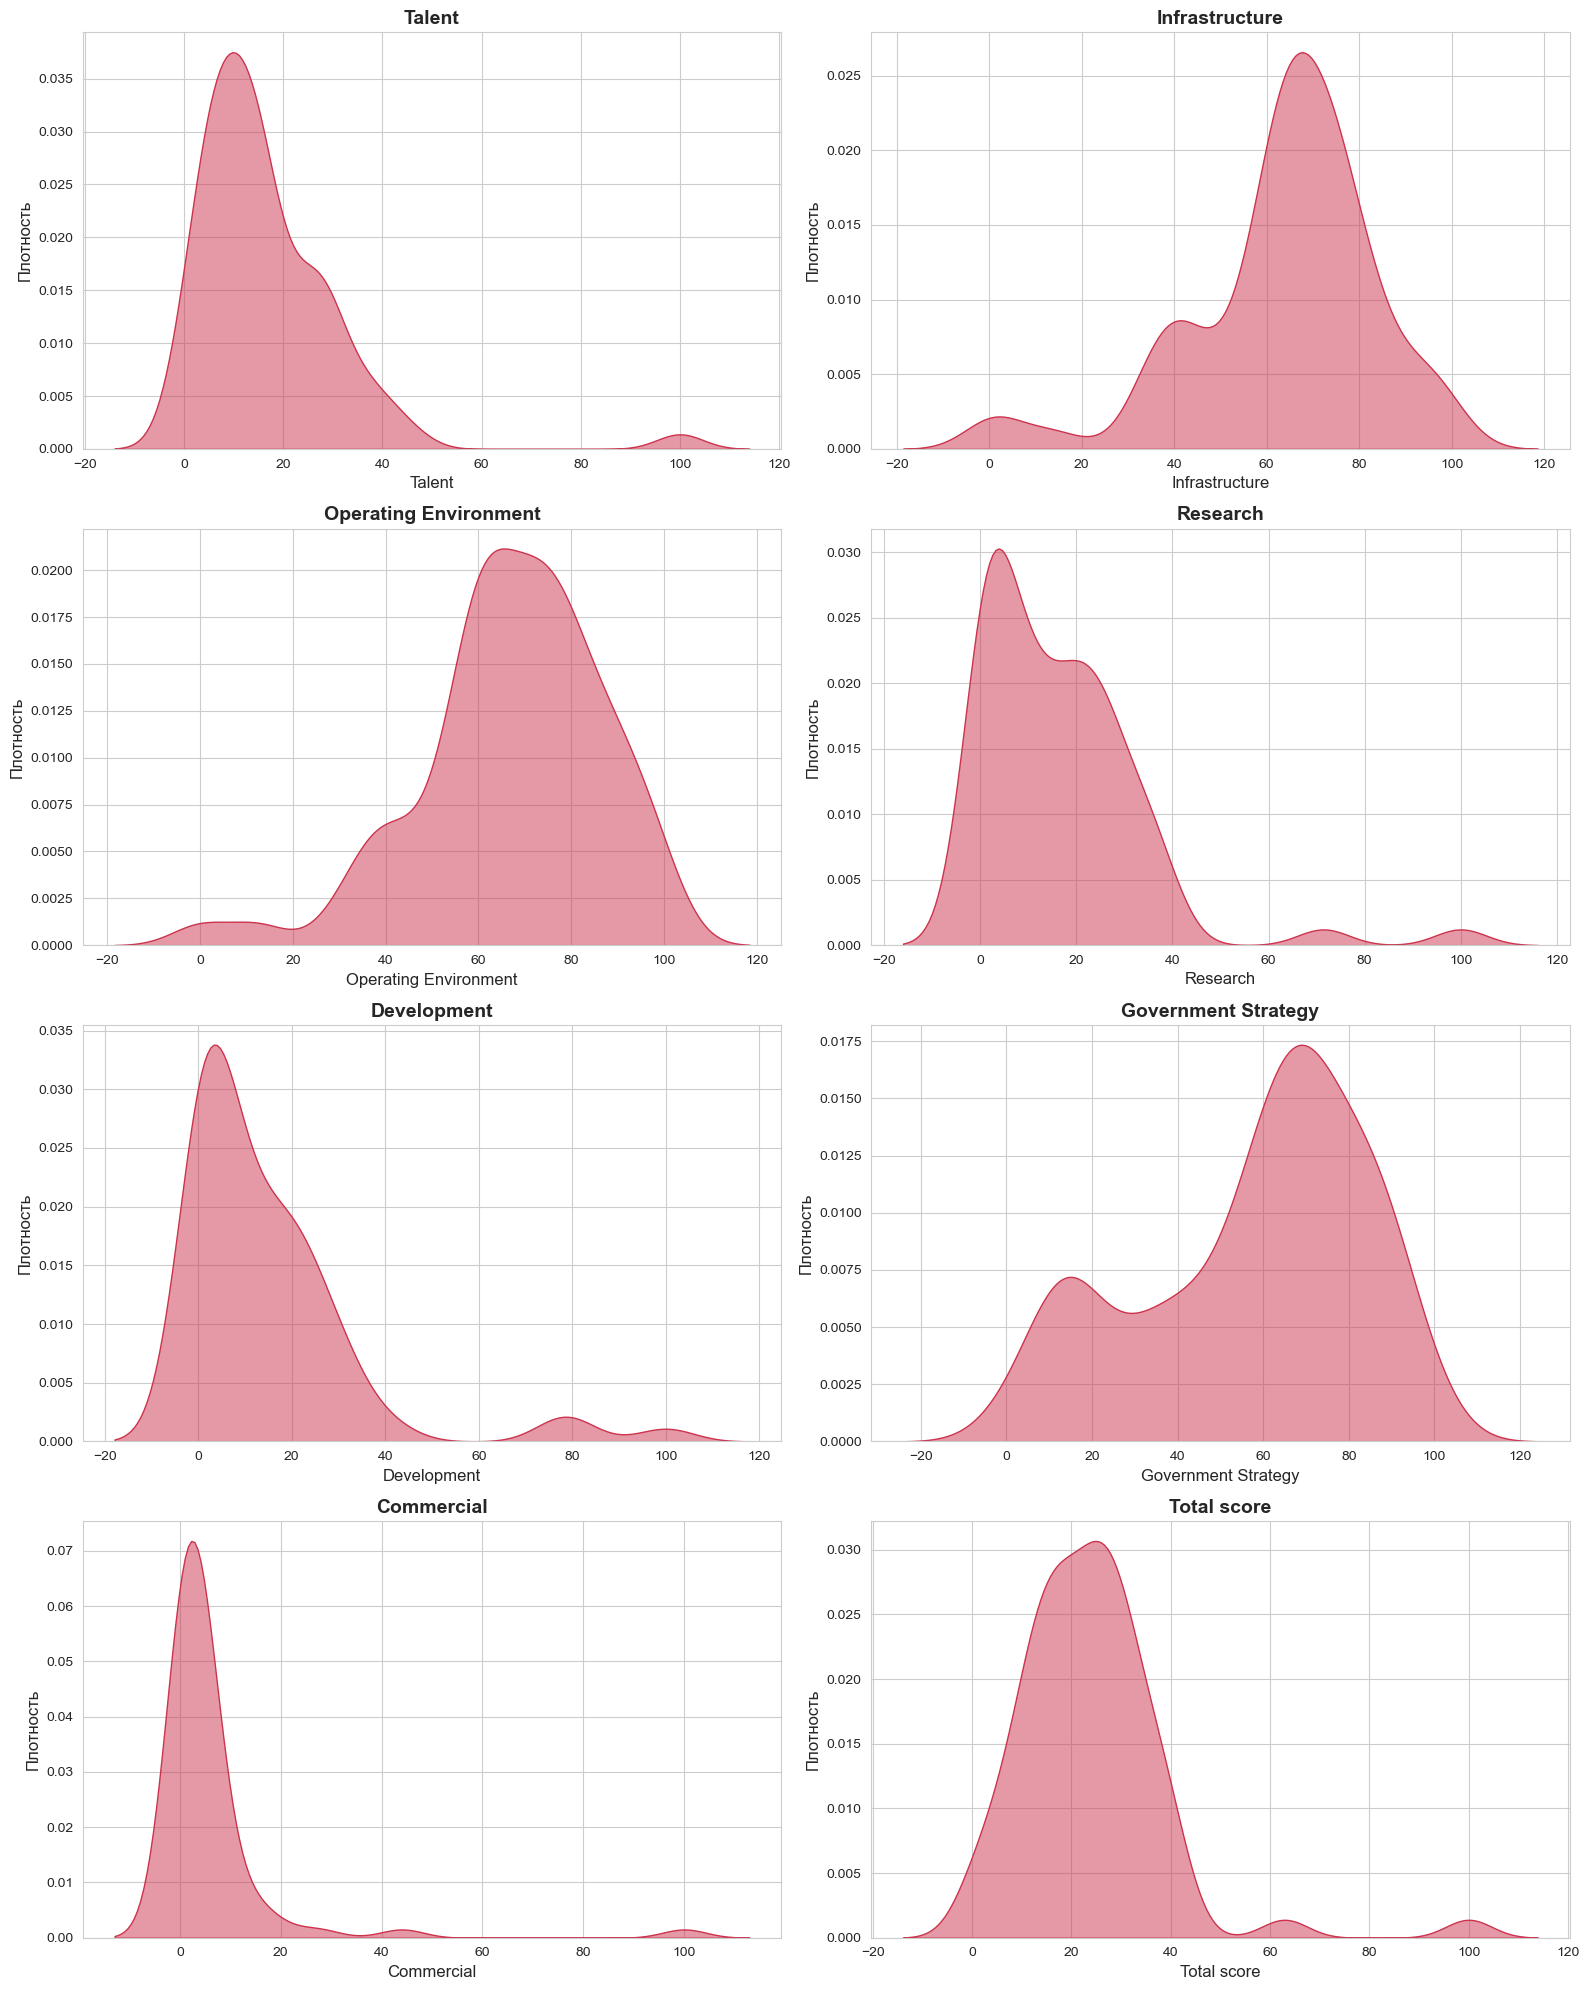


 Выводы:
   • Некоторые признаки близки к нормальному распределению
   • Остальные имеют скос или несколько мод
   • Признаки имеют разные масштабы измерений → нужна нормализация



In [7]:

features = ['Talent', 'Infrastructure', 'Operating Environment', 'Research', 
            'Development', 'Government Strategy', 'Commercial']

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()
plt.subplots_adjust(hspace=0.5)

for i, col in enumerate(features):
    sns.kdeplot(data=df, x=col, fill=True, alpha=0.5, bw_adjust=0.7, 
                color=[0.8, 0.2, 0.3], ax=axes[i])
    axes[i].set_title(col, fontweight='bold', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Плотность', fontsize=12)

sns.kdeplot(data=df, x='Total score', fill=True, alpha=0.5, bw_adjust=0.7, 
            color=[0.8, 0.2, 0.3], ax=axes[7])
axes[7].set_title('Total score', fontweight='bold', fontsize=14)
axes[7].set_xlabel('Total score', fontsize=12)
axes[7].set_ylabel('Плотность', fontsize=12)

plt.tight_layout()
plt.show()

print("""
 Выводы:
   • Некоторые признаки близки к нормальному распределению
   • Остальные имеют скос или несколько мод
   • Признаки имеют разные масштабы измерений → нужна нормализация
""")

## Выбросы данных

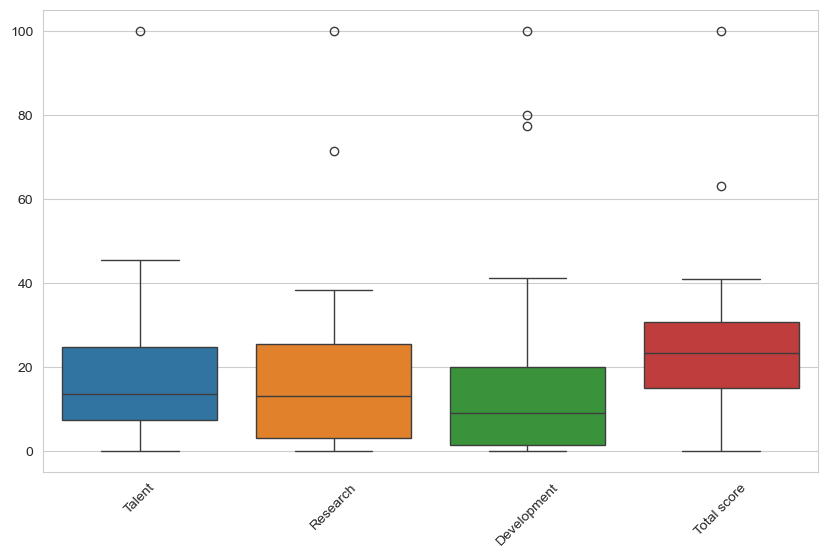

In [8]:
cols = ['Talent', 'Research', 'Development', 'Total score']
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[cols])
plt.xticks(rotation=45)
plt.show()

In [9]:
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"\n{col}:")
    print(f"  Границы: от {lower:.1f} до {upper:.1f}")
    print(f"  Найдено выбросов: {len(outliers)}")
    
    if len(outliers) > 0:
        print(f"  Страны: {', '.join(outliers['Country'].tolist())}")


Talent:
  Границы: от -18.4 до 50.4
  Найдено выбросов: 1
  Страны: United States of America

Research:
  Границы: от -30.5 до 59.0
  Найдено выбросов: 2
  Страны: United States of America, China

Development:
  Границы: от -27.0 до 48.1
  Найдено выбросов: 3
  Страны: United States of America, China, South Korea

Total score:
  Границы: от -8.7 до 54.0
  Найдено выбросов: 2
  Страны: United States of America, China


Размер: (62, 9)
Всего найдено выбросов: 20


,Talent,Infrastructure,Operating Environment,Research,Development,Government Strategy,Commercial,Total score,Total outliers
Country,,,,,,,,,
United States of America,1,0,0,1,1,0,1,1,5
China,0,0,0,1,1,0,1,1,4
United Kingdom,0,0,0,0,0,0,1,0,1
Canada,0,0,0,0,0,0,1,0,1
Israel,0,0,0,0,0,0,1,0,1
Singapore,0,0,0,0,0,0,1,0,1
South Korea,0,0,0,0,1,0,0,0,1
Estonia,0,0,0,0,0,0,1,0,1
Egypt,0,0,1,0,0,0,0,0,1


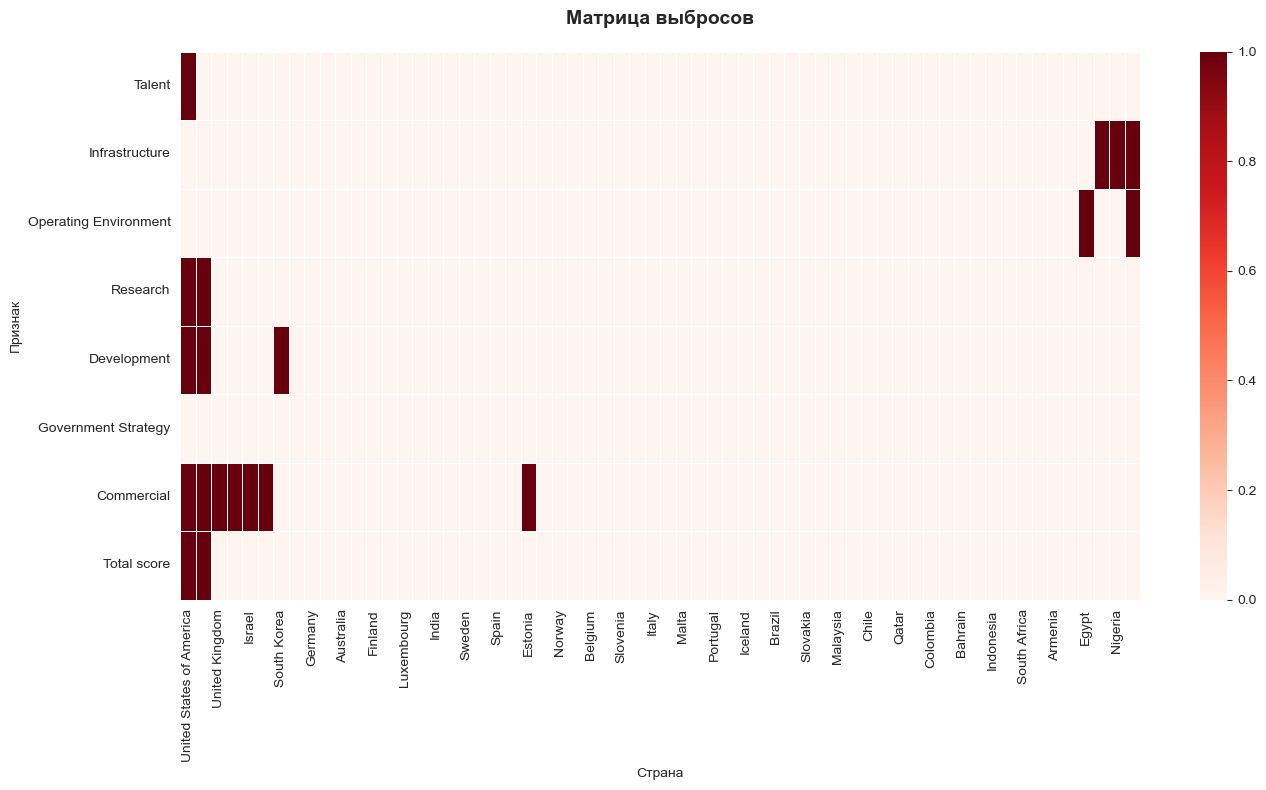

In [10]:
numeric_cols = ['Talent', 'Infrastructure', 'Operating Environment', 
                'Research', 'Development', 'Government Strategy', 
                'Commercial', 'Total score']

# Создаем DataFrame
outlier_summary = pd.DataFrame(index=df.index)

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    outlier_mask = (df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)
    outlier_summary[col] = outlier_mask.astype(int)

# Добавляем названия стран и устанавливаем как индекс
outlier_summary['Country'] = df['Country'].values
outlier_summary = outlier_summary.set_index('Country') 
outlier_summary['Total outliers'] = outlier_summary[numeric_cols].sum(axis=1)

# Проверяем
print(f"Размер: {outlier_summary.shape}")
print(f"Всего найдено выбросов: {outlier_summary['Total outliers'].sum()}")
display(outlier_summary[outlier_summary['Total outliers'] > 0].head(10))

# Рисуем heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(outlier_summary[numeric_cols].T, 
            cmap='Reds', 
            linewidths=0.5)
plt.title('Матрица выбросов', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Страна')
plt.ylabel('Признак')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## НОРМАЛИЗАЦИЯ ##

In [11]:
scaler = MinMaxScaler()
X = df[features].copy()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features)
display(X_scaled.describe().round(3))
print(" MinMaxScaler применён (диапазон [0, 1])")

,Talent,Infrastructure,Operating Environment,Research,Development,Government Strategy,Commercial
count,62.000,62.000,62.000,62.000,62.000,62.000,62.000
mean,0.168,0.635,0.669,0.166,0.148,0.579,0.062
std,0.152,0.202,0.200,0.174,0.194,0.263,0.140
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.074,0.559,0.581,0.030,0.012,0.410,0.007
50%,0.134,0.652,0.695,0.129,0.090,0.639,0.026
75%,0.246,0.759,0.805,0.254,0.200,0.780,0.053
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000


 MinMaxScaler применён (диапазон [0, 1])


## Моделирование ##

### Кластеризация стран

 Цели анализа:
 
   • Изучить закономерности в данных AI Index
   
   • Применить метод главных компонент (PCA)
   
   • Выполнить кластеризацию 3 методами
   
   • Сравнить результаты и проанализировать кластеры

In [12]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [13]:
features_for_clustering = ['Talent', 'Infrastructure', 'Operating Environment', 
                          'Research', 'Development', 'Government Strategy', 'Commercial']

X = df[features_for_clustering].copy()
print("\nРазмер матрицы признаков:", X.shape)
X.head()


Размер матрицы признаков: (62, 7)


,Talent,Infrastructure,Operating Environment,Research,Development,Government Strategy,Commercial
0,100.00,94.02,64.56,100.00,100.00,77.39,100.00
1,16.51,100.00,91.57,71.42,79.97,94.87,44.02
2,39.65,71.43,74.65,36.50,25.03,82.82,18.91
3,31.28,77.05,93.94,30.67,25.78,100.00,14.88
4,35.76,67.58,82.44,32.63,27.96,43.91,27.33


In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features_for_clustering)

print("Данные после масштабирования:")
X_scaled_df.head()

Данные после масштабирования:


,Talent,Infrastructure,Operating Environment,Research,Development,Government Strategy,Commercial
0,5.512738,1.521720,-0.119237,4.827769,4.421927,0.749787,6.742445
1,-0.019419,1.819917,1.242259,3.173162,3.382058,1.421065,2.719746
2,1.513868,0.395251,0.389370,1.151509,0.529815,0.958313,0.915352
3,0.959261,0.675497,1.361723,0.813988,0.568752,1.618071,0.625758
4,1.256111,0.203268,0.782042,0.927460,0.681928,-0.535934,1.520410


МЕТОД ЛОКТЯ (Elbow Method)

In [15]:
inertia = [] 
K_range = range(2, 11) 

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_) 

  File "C:\Users\Liliann\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Liliann\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Liliann\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Liliann\anaconda3\Lib\sub

МЕТОД СИЛУЭТА (Silhouette Method)

In [16]:
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

Визуализируем оба метода

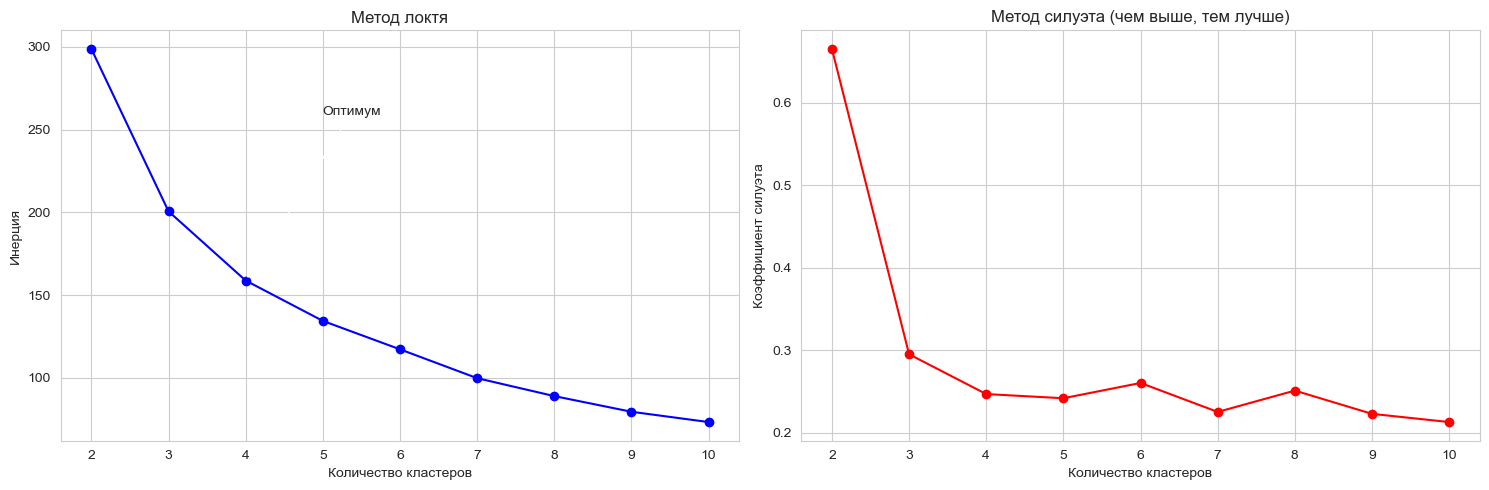

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# График локтя
ax1.plot(K_range, inertia, 'bo-')
ax1.set_xlabel('Количество кластеров')
ax1.set_ylabel('Инерция')
ax1.set_title('Метод локтя')
ax1.grid(True)
ax1.annotate('Оптимум', xy=(4, inertia[2]), xytext=(5, inertia[2]+100),
            arrowprops=dict(arrowstyle='->'))

# График силуэта
ax2.plot(K_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Количество кластеров')
ax2.set_ylabel('Коэффициент силуэта')
ax2.set_title('Метод силуэта (чем выше, тем лучше)')
ax2.grid(True)

plt.tight_layout()
plt.show()


In [18]:
best_k = K_range[np.argmax(silhouette_scores)]
print(f"Оптимальное количество кластеров: {best_k}")
print(f"Коэффициент силуэта: {max(silhouette_scores):.3f}")

Оптимальное количество кластеров: 2
Коэффициент силуэта: 0.665


### Метод - K-MEANS

In [19]:
n_clusters = 4

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

df_kmeans = df.copy()
df_kmeans['Cluster_KMeans'] = kmeans_labels

kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
print(f"Коэффициент силуэта = {kmeans_silhouette:.3f}")

print("\nРаспределение по кластерам K-Means:")
print(df_kmeans['Cluster_KMeans'].value_counts().sort_index())

print("\nПримеры стран в каждом кластере K-Means:")
for cluster in range(n_clusters):
    countries = df_kmeans[df_kmeans['Cluster_KMeans'] == cluster]['Country'].head(3).tolist()
    print(f"Кластер {cluster}: {', '.join(countries)}")

Коэффициент силуэта = 0.247

Распределение по кластерам K-Means:
Cluster_KMeans
0    27
1    21
2    13
3     1
Name: count, dtype: int64

Примеры стран в каждом кластере K-Means:
Кластер 0: Spain, Austria, Estonia
Кластер 1: China, United Kingdom, Canada
Кластер 2: Iceland, Bahrain, Vietnam
Кластер 3: United States of America


### Метод - Agglomerative (Иерархическая)

In [20]:
agglo = AgglomerativeClustering(n_clusters=n_clusters)
agglo_labels = agglo.fit_predict(X_scaled)

df_agglo = df.copy()
df_agglo['Cluster_Agglo'] = agglo_labels

agglo_silhouette = silhouette_score(X_scaled, agglo_labels)
print(f"Коэффициент силуэта = {agglo_silhouette:.3f}")

print("\nРаспределение по кластерам Agglomerative:")
print(df_agglo['Cluster_Agglo'].value_counts().sort_index())

print("\nПримеры стран в каждом кластере Agglomerative:")
for cluster in range(n_clusters):
    countries = df_agglo[df_agglo['Cluster_Agglo'] == cluster]['Country'].head(3).tolist()
    print(f"Кластер {cluster}: {', '.join(countries)}")

Коэффициент силуэта = 0.167

Распределение по кластерам Agglomerative:
Cluster_Agglo
0    26
1    16
2    19
3     1
Name: count, dtype: int64

Примеры стран в каждом кластере Agglomerative:
Кластер 0: China, United Kingdom, Canada
Кластер 1: Austria, Estonia, Saudi Arabia
Кластер 2: Greece, Hungary, Chile
Кластер 3: United States of America


### Метод - DBSCAN (Плотностная)

In [21]:
eps_values = [0.5, 0.7, 0.9, 1.1]
min_samples_values = [3, 4, 5]

best_score = -1
best_eps = None
best_min_samples = None
best_labels = None

print("Параметры:")
for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        print(f"eps={eps}, min_samples={min_samples}: кластеров={n_clusters}, шум={n_noise}")
        
        if n_clusters > 1 and n_noise < 10:
            try:
                mask = labels != -1
                score = silhouette_score(X_scaled[mask], labels[mask])
                if score > best_score:
                    best_score = score
                    best_eps = eps
                    best_min_samples = min_samples
                    best_labels = labels
            except:
                pass

if best_labels is not None:
    dbscan_labels = best_labels
    print(f"\nЛУЧШИЕ ПАРАМЕТРЫ:")
    print(f"eps={best_eps}, min_samples={best_min_samples}")
    print(f"Силуэт (без шума): {best_score:.3f}")
else:
    dbscan = DBSCAN(eps=0.8, min_samples=3)
    dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"\nРЕЗУЛЬТАТЫ DBSCAN:")
print(f"Количество кластеров: {n_clusters_db}")
print(f"Количество выбросов (шум): {n_noise}")
print(f"Процент выбросов: {n_noise/len(dbscan_labels)*100:.1f}%")

df_dbscan = df.copy()
df_dbscan['Cluster'] = dbscan_labels

print("\n Состав кластеров:")
for cluster in sorted(set(dbscan_labels)):
    if cluster == -1:
        countries = df_dbscan[df_dbscan['Cluster'] == cluster]['Country'].tolist()
        print(f"\n ВЫБРОСЫ ({len(countries)} стран):")
        print(', '.join(countries[:10])) 
    else:
        countries = df_dbscan[df_dbscan['Cluster'] == cluster]['Country'].tolist()
        print(f"\n Кластер {cluster} ({len(countries)} стран):")
        print(', '.join(countries[:5]))

Параметры:
eps=0.5, min_samples=3: кластеров=2, шум=55
eps=0.5, min_samples=4: кластеров=1, шум=58
eps=0.5, min_samples=5: кластеров=0, шум=62
eps=0.7, min_samples=3: кластеров=2, шум=54
eps=0.7, min_samples=4: кластеров=1, шум=57
eps=0.7, min_samples=5: кластеров=1, шум=57
eps=0.9, min_samples=3: кластеров=3, шум=35
eps=0.9, min_samples=4: кластеров=3, шум=41
eps=0.9, min_samples=5: кластеров=3, шум=43
eps=1.1, min_samples=3: кластеров=1, шум=28
eps=1.1, min_samples=4: кластеров=1, шум=28
eps=1.1, min_samples=5: кластеров=1, шум=31

РЕЗУЛЬТАТЫ DBSCAN:
Количество кластеров: 3
Количество выбросов (шум): 42
Процент выбросов: 67.7%

 Состав кластеров:

 ВЫБРОСЫ (42 стран):
United States of America, China, United Kingdom, Canada, Israel, Singapore, South Korea, The Netherlands, Germany, Australia

 Кластер 0 (4 стран):
France, Finland, Denmark, Spain

 Кластер 1 (3 стран):
Austria, Belgium, Italy

 Кластер 2 (13 стран):
Malta, Portugal, Czech Republic, Lithuania, Brazil


### Сравнение методов кластеризации

In [22]:
# K-Means
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Иерархическая кластеризация (ВАЖНО: создаем hier_labels)
from sklearn.cluster import AgglomerativeClustering
hierarchical = AgglomerativeClustering(n_clusters=4)
hier_labels = hierarchical.fit_predict(X_scaled)  # вот эту переменную используем потом

# DBSCAN
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.9, min_samples=3)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Считаем метрики для DBSCAN
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

In [23]:
# Создаем таблицу сравнения
comparison = pd.DataFrame({
    'Метод': ['K-Means', 'Иерархическая', 'DBSCAN'],
    'Силуэт': [
        silhouette_score(X_scaled, kmeans_labels),
        silhouette_score(X_scaled, hier_labels),  # теперь hier_labels определена
        silhouette_score(X_scaled[dbscan_labels != -1], dbscan_labels[dbscan_labels != -1]) if n_noise > 0 else silhouette_score(X_scaled, dbscan_labels)
    ],
    'Кластеров': [
        len(set(kmeans_labels)),
        len(set(hier_labels)),  # теперь hier_labels определена
        n_clusters_db
    ],
    'Выбросы': [
        0,
        0,
        n_noise
    ]
})

print("\nТАБЛИЦА СРАВНЕНИЯ:")
print(comparison.round(3))


ТАБЛИЦА СРАВНЕНИЯ:
           Метод  Силуэт  Кластеров  Выбросы
0        K-Means   0.247          4        0
1  Иерархическая   0.167          4        0
2         DBSCAN   0.257          3       35


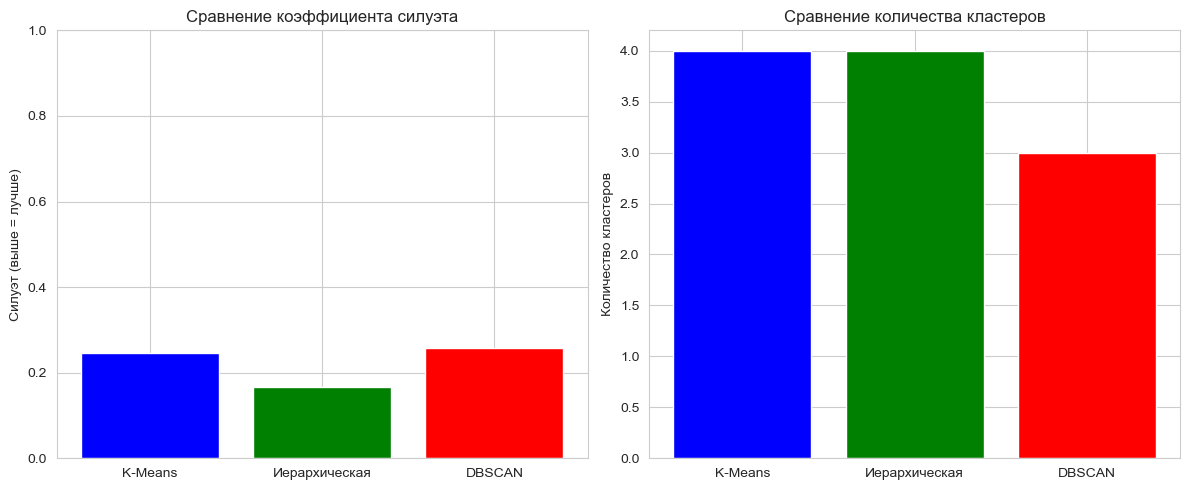

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(comparison['Метод'], comparison['Силуэт'], color=['blue', 'green', 'red'])
axes[0].set_title('Сравнение коэффициента силуэта')
axes[0].set_ylabel('Силуэт (выше = лучше)')
axes[0].set_ylim(0, 1)

axes[1].bar(comparison['Метод'], comparison['Кластеров'], color=['blue', 'green', 'red'])
axes[1].set_title('Сравнение количества кластеров')
axes[1].set_ylabel('Количество кластеров')

plt.tight_layout()
plt.show()

In [25]:
best_method = comparison.loc[comparison['Силуэт'].idxmax(), 'Метод']
print(f"\n Лучший метод: {best_method}")


 Лучший метод: DBSCAN


In [26]:
# Создаем DataFrame для сравнения
comparison_df = df[['Country']].copy()
comparison_df['K-Means'] = kmeans_labels
comparison_df['Agglomerative'] = agglo_labels
comparison_df['DBSCAN'] = dbscan_labels

# Добавляем регион для контекста
comparison_df['Region'] = df['Region']

print("Сравнение кластеризации для первых 15 стран:")
comparison_df.head(15)

Сравнение кластеризации для первых 15 стран:


,Country,K-Means,Agglomerative,DBSCAN,Region
0,United States of America,3,3,-1,Americas
1,China,1,0,-1,Asia-Pacific
2,United Kingdom,1,0,-1,Europe
3,Canada,1,0,-1,Americas
4,Israel,1,0,-1,Middle East
5,Singapore,1,0,-1,Asia-Pacific
6,South Korea,1,0,-1,Asia-Pacific
7,The Netherlands,1,0,-1,Europe
8,Germany,1,0,0,Europe
9,France,1,0,0,Europe


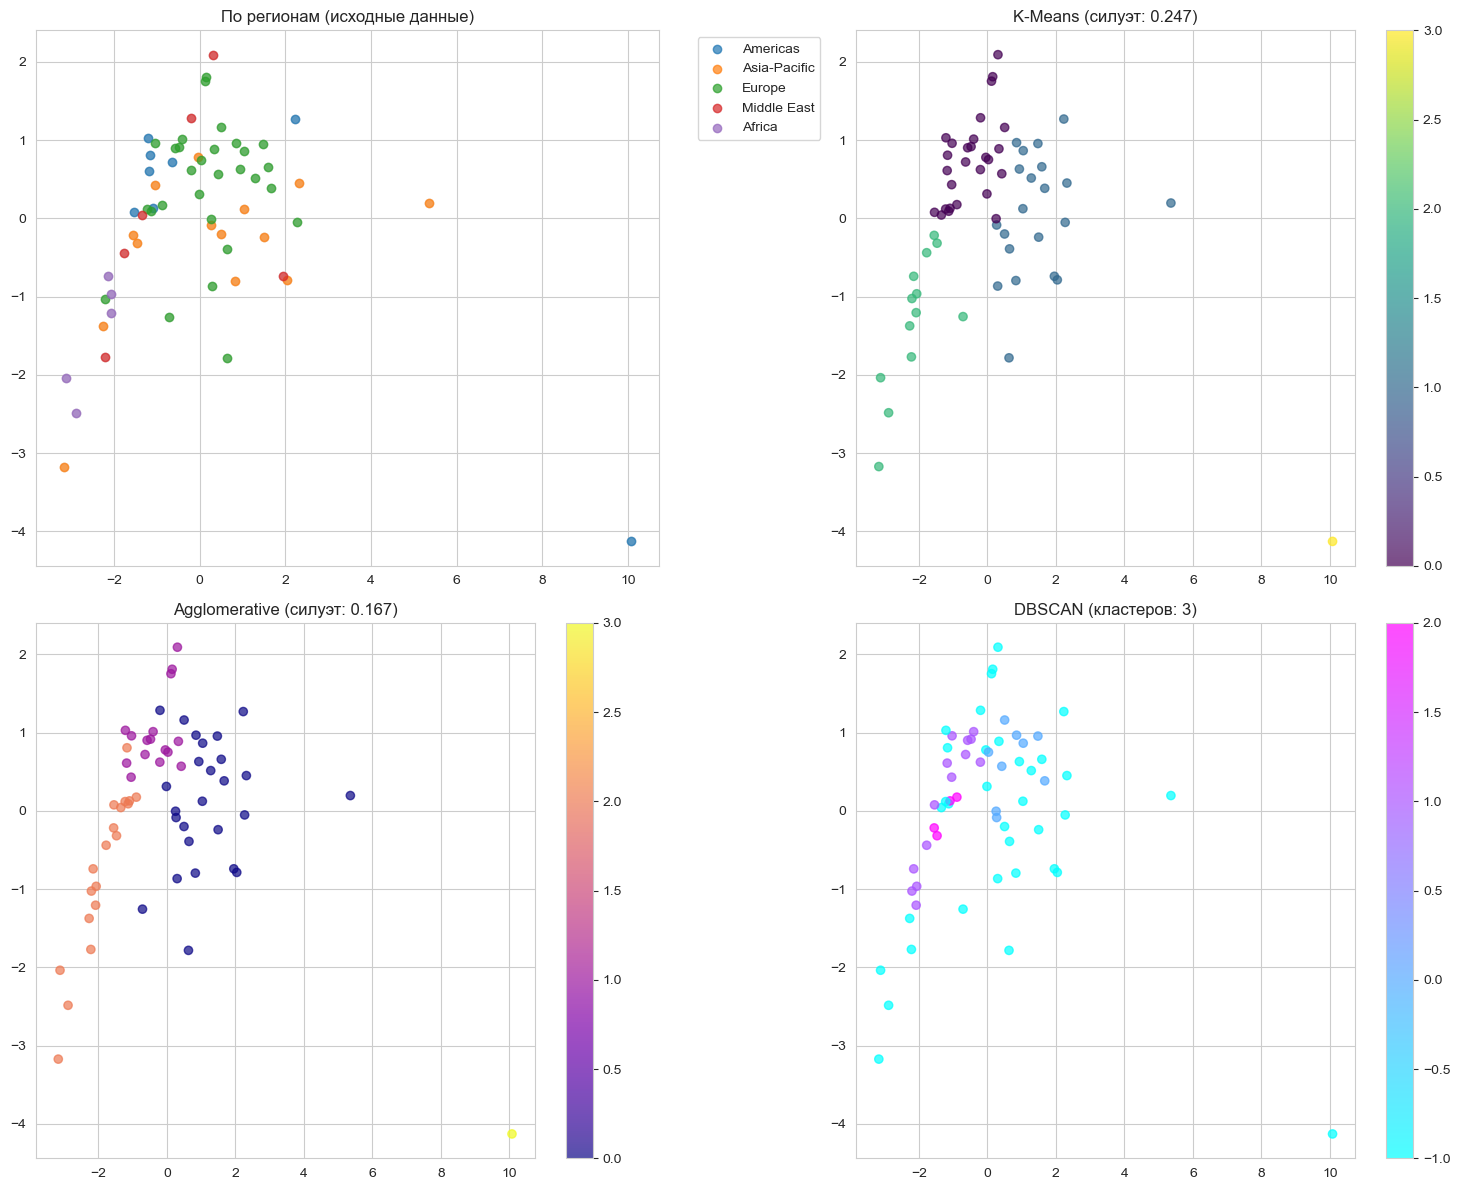

In [27]:
# Создаем 2D визуализацию с помощью PCA (уменьшаем размерность до 2)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Создаем DataFrame для визуализации
viz_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Country': df['Country'],
    'Region': df['Region'],
    'KMeans': kmeans_labels,
    'Agglo': agglo_labels,
    'DBSCAN': dbscan_labels
})

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# По регионам
axes[0, 0].scatter(viz_df['PC1'], viz_df['PC2'], c='lightgray', alpha=0.6)
for region in viz_df['Region'].unique():
    mask = viz_df['Region'] == region
    axes[0, 0].scatter(viz_df.loc[mask, 'PC1'], viz_df.loc[mask, 'PC2'], 
                       label=region, alpha=0.7)
axes[0, 0].set_title('По регионам (исходные данные)')
axes[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# K-Means
scatter = axes[0, 1].scatter(viz_df['PC1'], viz_df['PC2'], 
                             c=viz_df['KMeans'], cmap='viridis', alpha=0.7)
axes[0, 1].set_title(f'K-Means (силуэт: {kmeans_silhouette:.3f})')
plt.colorbar(scatter, ax=axes[0, 1])

# Agglomerative
scatter = axes[1, 0].scatter(viz_df['PC1'], viz_df['PC2'], 
                             c=viz_df['Agglo'], cmap='plasma', alpha=0.7)
axes[1, 0].set_title(f'Agglomerative (силуэт: {agglo_silhouette:.3f})')
plt.colorbar(scatter, ax=axes[1, 0])

# DBSCAN
scatter = axes[1, 1].scatter(viz_df['PC1'], viz_df['PC2'], 
                             c=viz_df['DBSCAN'], cmap='cool', alpha=0.7)
axes[1, 1].set_title(f'DBSCAN (кластеров: {n_clusters_db})')
plt.colorbar(scatter, ax=axes[1, 1])

plt.tight_layout()
plt.show()

### МЕТОД ГЛАВНЫХ КОМПОНЕНТ (PCA - ВИЗУАЛИЗАЦИЯ КЛАСТЕРОВ) 

PC1 сохраняет: 58.1% информации
PC2 сохраняет: 19.1% информации
ВСЕГО сохранили: 77.3% информации

ВАЖНОСТЬ ПРИЗНАКОВ В КОМПОНЕНТАХ:
     Talent  Infrastructure  Operating Environment  Research  Development  \
PC1   0.422           0.356                  0.174     0.466        0.436   
PC2  -0.226           0.363                  0.639    -0.167       -0.162   

     Government Strategy  Commercial  
PC1                0.284       0.421  
PC2                0.497      -0.328  


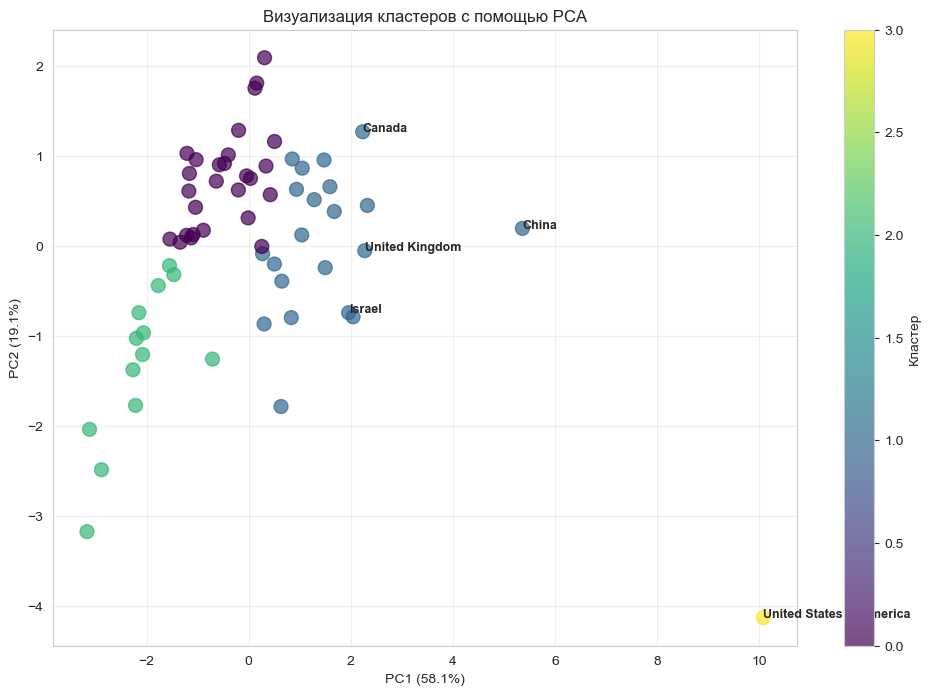

In [28]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
print(f"PC1 сохраняет: {explained_variance[0]:.1%} информации")
print(f"PC2 сохраняет: {explained_variance[1]:.1%} информации")
print(f"ВСЕГО сохранили: {sum(explained_variance):.1%} информации")

components = pd.DataFrame(
    pca.components_,
    columns=features,
    index=['PC1', 'PC2']
)
print("\nВАЖНОСТЬ ПРИЗНАКОВ В КОМПОНЕНТАХ:")
print(components.round(3))


final_labels = kmeans_labels  

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=final_labels, cmap='viridis', 
                     s=100, alpha=0.7)

top_countries = df.nlargest(5, 'Total score')['Country'].tolist()
for i, country in enumerate(df['Country']):
    if country in top_countries:
        plt.annotate(country, (X_pca[i, 0], X_pca[i, 1]), 
                    fontsize=9, fontweight='bold')

plt.colorbar(scatter, label='Кластер')
plt.xlabel(f'PC1 ({explained_variance[0]:.1%})')
plt.ylabel(f'PC2 ({explained_variance[1]:.1%})')
plt.title('Визуализация кластеров с помощью PCA')
plt.grid(True, alpha=0.3)
plt.show()

# Классификация

### (3 метода) с метриками

In [29]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)
from sklearn.preprocessing import StandardScaler
import joblib
import seaborn as sns

## 1. Создание целевой переменной

In [30]:
# Создаем бинарную целевую переменную на основе Total score
median_score = df['Total score'].median()
df['Target'] = (df['Total score'] >= median_score).astype(int)

print(f"Медианный балл: {median_score:.2f}")
print(f"Распределение целевой переменной:")
print(df['Target'].value_counts())
print(f"\nКласс 0 (Low): {df[df['Target']==0]['Total score'].mean():.2f}")
print(f"Класс 1 (High): {df[df['Target']==1]['Total score'].mean():.2f}")

Медианный балл: 23.22
Распределение целевой переменной:
Target
1    31
0    31
Name: count, dtype: int64

Класс 0 (Low): 13.61
Класс 1 (High): 34.22


## 2. Подготовка данных

In [31]:
features_class = ['Talent', 'Infrastructure', 'Operating Environment', 
                  'Research', 'Development', 'Government Strategy', 'Commercial']

X = df[features_class].values
y = df['Target'].values

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                                     random_state=42, stratify=y)

# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 3. Обучение моделей

In [68]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}

print("ОБУЧЕНИЕ И ОЦЕНКА МОДЕЛЕЙ:")

for name, model in models.items():
    # Обучение
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Метрики
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Кросс-валидация
    if name == 'Logistic Regression':
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1')
    else:
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
    
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }
    
    print(f"\n{name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-score:  {f1:.4f}")
    print(f"  ROC-AUC:   {roc_auc:.4f}")
    print(f"  CV F1:     {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

ОБУЧЕНИЕ И ОЦЕНКА МОДЕЛЕЙ:

Logistic Regression:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-score:  1.0000
  ROC-AUC:   1.0000
  CV F1:     0.9778 (+/- 0.0444)

Random Forest:
  Accuracy:  0.8421
  Precision: 1.0000
  Recall:    0.6667
  F1-score:  0.8000
  ROC-AUC:   1.0000
  CV F1:     0.8833 (+/- 0.0793)

Gradient Boosting:
  Accuracy:  0.8421
  Precision: 1.0000
  Recall:    0.6667
  F1-score:  0.8000
  ROC-AUC:   0.8333
  CV F1:     0.9278 (+/- 0.0988)


## 4. Сравнение моделей

In [69]:
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results],
    'Precision': [results[m]['precision'] for m in results],
    'Recall': [results[m]['recall'] for m in results],
    'F1-score': [results[m]['f1'] for m in results],
    'ROC-AUC': [results[m]['roc_auc'] for m in results],
    'CV F1': [results[m]['cv_mean'] for m in results]
}).round(4)

print("СРАВНЕНИЕ МОДЕЛЕЙ:")

print(results_df.to_string(index=False))

СРАВНЕНИЕ МОДЕЛЕЙ:
              Model  Accuracy  Precision  Recall  F1-score  ROC-AUC  CV F1
Logistic Regression    1.0000        1.0  1.0000       1.0   1.0000 0.9778
      Random Forest    0.8421        1.0  0.6667       0.8   1.0000 0.8833
  Gradient Boosting    0.8421        1.0  0.6667       0.8   0.8333 0.9278


## 5. Выбор лучшей модели

In [70]:
best_model_name = results_df.loc[results_df['F1-score'].idxmax(), 'Model']
best_model = results[best_model_name]['model']

print(f"\nЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
print(f"   F1-score: {results[best_model_name]['f1']:.4f}")
print(f"   ROC-AUC: {results[best_model_name]['roc_auc']:.4f}")


ЛУЧШАЯ МОДЕЛЬ: Logistic Regression
   F1-score: 1.0000
   ROC-AUC: 1.0000


## 6. Сохранение лучшей модели

In [71]:
joblib.dump(best_model, 'best_classifier.joblib')
joblib.dump(scaler, 'scaler.joblib')
print("\nМодель и скалер сохранены!")


Модель и скалер сохранены!


## 7. Визуализация метрик

In [73]:
# 1. Сравнение метрик
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
metrics_mapping = {
    'Accuracy': 'accuracy',
    'Precision': 'precision', 
    'Recall': 'recall',
    'F1-score': 'f1',
    'ROC-AUC': 'roc_auc'
}

x = np.arange(len(metrics))
width = 0.25

for i, (name, result) in enumerate(results.items()):
    values = [result[metrics_mapping[m]] for m in metrics]
    axes[0, 0].bar(x + i*width, values, width, label=name)

axes[0, 0].set_xlabel('Метрика')
axes[0, 0].set_ylabel('Значение')
axes[0, 0].set_title('Сравнение метрик классификации')
axes[0, 0].set_xticks(x + width)
axes[0, 0].set_xticklabels(metrics, rotation=45)
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].set_ylim(0, 1.1)

(0.0, 1.1)

In [74]:
# 2. ROC кривые 
for name, result in results.items():
    model = result['model']
    if name == 'Logistic Regression':
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    axes[0, 1].plot(fpr, tpr, label=f'{name} (AUC = {result["roc_auc"]:.3f})')

axes[0, 1].plot([0, 1], [0, 1], 'k--')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC кривые')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

In [75]:
# 3. Матрица ошибок лучшей модели
if best_model_name == 'Logistic Regression':
    y_pred_best = best_model.predict(X_test_scaled)
else:
    y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0])
axes[1, 0].set_xlabel('Предсказанный')
axes[1, 0].set_ylabel('Фактический')
axes[1, 0].set_title(f'Матрица ошибок - {best_model_name}')

Text(0.5, 1.0, 'Матрица ошибок - Logistic Regression')

In [76]:
# 4. Важность признаков (для Random Forest или Gradient Boosting)
if best_model_name in ['Random Forest', 'Gradient Boosting']:
    importances = best_model.feature_importances_
else:
    importances = np.abs(results['Logistic Regression']['model'].coef_[0])

indices = np.argsort(importances)[::-1]
axes[1, 1].barh(range(len(features_class)), importances[indices])
axes[1, 1].set_yticks(range(len(features_class)))
axes[1, 1].set_yticklabels([features_class[i] for i in indices])
axes[1, 1].set_xlabel('Важность')
axes[1, 1].set_title('Важность признаков')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

In [78]:
# Отчет по классификации
print("ОТЧЕТ ПО КЛАССИФИКАЦИИ")

if best_model_name == 'Logistic Regression':
    print(classification_report(y_test, best_model.predict(X_test_scaled), 
                                target_names=['Low AI', 'High AI']))
else:
    print(classification_report(y_test, best_model.predict(X_test), 
                                target_names=['Low AI', 'High AI']))

ОТЧЕТ ПО КЛАССИФИКАЦИИ
              precision    recall  f1-score   support

      Low AI       1.00      1.00      1.00        10
     High AI       1.00      1.00      1.00         9

    accuracy                           1.00        19
   macro avg       1.00      1.00      1.00        19
weighted avg       1.00      1.00      1.00        19



# Интерактивный дашборд

### (5 визуализацией, 3 фильтра)

In [81]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display, clear_output

In [82]:
# Добавляем результаты кластеризации и классификации в DataFrame
df['Cluster'] = kmeans_labels  # из предыдущего раздела

In [83]:
# Предсказания лучшей модели
if best_model_name == 'Logistic Regression':
    df['Prediction'] = best_model.predict(scaler.transform(df[features_class].values))
    df['Prediction_Proba'] = best_model.predict_proba(scaler.transform(df[features_class].values))[:, 1]
else:
    df['Prediction'] = best_model.predict(df[features_class].values)
    df['Prediction_Proba'] = best_model.predict_proba(df[features_class].values)[:, 1]

## Создание интерактивного дашборда

In [84]:
# 1. Фильтры
region_filter = widgets.Dropdown(
    options=['All'] + list(df['Region'].unique()),
    value='All',
    description='Регион:'
)

income_filter = widgets.Dropdown(
    options=['All'] + list(df['Income group'].unique()),
    value='All',
    description='Доход:'
)

cluster_filter = widgets.Dropdown(
    options=['All'] + [str(i) for i in range(len(df['Cluster'].unique()))],
    value='All',
    description='Кластер:'
)

score_range = widgets.FloatRangeSlider(
    value=[df['Total score'].min(), df['Total score'].max()],
    min=df['Total score'].min(),
    max=df['Total score'].max(),
    step=1,
    description='Total Score:'
)

In [85]:
# 2. Функция фильтрации
def filter_data(region, income, cluster, score_min, score_max):
    filtered = df.copy()
    
    if region != 'All':
        filtered = filtered[filtered['Region'] == region]
    if income != 'All':
        filtered = filtered[filtered['Income group'] == income]
    if cluster != 'All':
        filtered = filtered[filtered['Cluster'] == int(cluster)]
    
    filtered = filtered[(filtered['Total score'] >= score_min) & 
                        (filtered['Total score'] <= score_max)]
    
    return filtered

In [86]:
# 3. Функция обновления дашборда
def update_dashboard(change=None):
    try:
        clear_output(wait=True)
        
        # Применяем фильтры
        filtered_df = filter_data(
            region_filter.value,
            income_filter.value,
            cluster_filter.value,
            score_range.value[0],
            score_range.value[1]
        )
        
        if len(filtered_df) == 0:
            print("Нет данных для выбранных фильтров!")
            return
        
        print(f"Показано стран: {len(filtered_df)} из {len(df)}")
        print(f"Регион: {region_filter.value}, Доход: {income_filter.value}, "
              f"Кластер: {cluster_filter.value}")
        print(f"Диапазон Total Score: {score_range.value[0]:.1f} - {score_range.value[1]:.1f}")
        print("="*80)
        
        # Создаем фигуру с 6 визуализациями
        fig = make_subplots(
            rows=2, cols=3,
            subplot_titles=(
                '1. Распределение целевой переменной',
                '2. Важность признаков',
                '3. Результаты кластеризации (PCA)',
                '4. Метрики классификации',
                '5. Сводная таблица',
                '6. Total Score по регионам'
            ),
            specs=[[{"type": "bar"}, {"type": "bar"}, {"type": "scatter"}],
                   [{"type": "bar"}, {"type": "table"}, {"type": "bar"}]],
            vertical_spacing=0.15,
            horizontal_spacing=0.12
        )
        
        # 1. Распределение целевой переменной
        target_dist = filtered_df['Target'].value_counts().sort_index()
        if len(target_dist) > 0:
            fig.add_trace(
                go.Bar(x=['Low AI', 'High AI'], y=target_dist.values,
                       marker_color=['#FF6B6B', '#4ECDC4'],
                       text=target_dist.values, textposition='auto'),
                row=1, col=1
            )
        
        # 2. Важность признаков
        if best_model_name in ['Random Forest', 'Gradient Boosting']:
            importances = best_model.feature_importances_
        else:
            importances = np.abs(results['Logistic Regression']['model'].coef_[0])
        
        feat_imp = pd.DataFrame({
            'Feature': features_class,
            'Importance': importances
        }).sort_values('Importance', ascending=True)
        
        fig.add_trace(
            go.Bar(x=feat_imp['Importance'], y=feat_imp['Feature'],
                   orientation='h', marker_color='#45B7D1'),
            row=1, col=2
        )
        
        # 3. Результаты кластеризации (PCA)
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(df[features_class].values)
        df_pca = df.copy()
        df_pca['PC1'] = X_pca[:, 0]
        df_pca['PC2'] = X_pca[:, 1]
        
        filtered_pca = df_pca[df_pca.index.isin(filtered_df.index)]
        
        for cluster in sorted(filtered_pca['Cluster'].unique()):
            cluster_data = filtered_pca[filtered_pca['Cluster'] == cluster]
            fig.add_trace(
                go.Scatter(x=cluster_data['PC1'], y=cluster_data['PC2'],
                          mode='markers', name=f'Cluster {cluster}',
                          marker=dict(size=10, opacity=0.7)),
                row=1, col=3
            )
        
        # 4. Метрики классификации
        metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
        metrics_mapping = {
            'Accuracy': 'accuracy',
            'Precision': 'precision', 
            'Recall': 'recall',
            'F1-score': 'f1',
            'ROC-AUC': 'roc_auc'
        }
        metrics_values = [results[best_model_name][metrics_mapping[m]] for m in metrics_names]
        
        fig.add_trace(
            go.Bar(x=metrics_names, y=metrics_values,
                   marker_color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8'],
                   text=[f'{v:.3f}' for v in metrics_values], textposition='auto'),
            row=2, col=1
        )
        fig.update_yaxes(range=[0, 1.1], row=2, col=1)
        
        # 5. Сводная таблица
        table_data = filtered_df[['Country', 'Total score', 'Cluster', 'Target', 'Prediction']].head(10)
        table_data.columns = ['Страна', 'Total Score', 'Кластер', 'Факт', 'Прогноз']
        
        fig.add_trace(
            go.Table(
                header=dict(values=list(table_data.columns),
                           fill_color='#45B7D1', align='center', font=dict(color='white', size=12)),
                cells=dict(values=[table_data[col] for col in table_data.columns],
                          fill_color='white', align='center', font=dict(size=10))
            ),
            row=2, col=2
        )
        
        # 6. Total Score по регионам
        region_scores = filtered_df.groupby('Region')['Total score'].agg(['mean', 'count']).reset_index()
        region_scores = region_scores[region_scores['count'] > 0]
        
        if len(region_scores) > 0:
            fig.add_trace(
                go.Bar(x=region_scores['Region'], y=region_scores['mean'],
                       marker_color='#FFA07A',
                       text=[f'{v:.1f}' for v in region_scores['mean']], textposition='auto'),
                row=2, col=3
            )
        
        # Обновление макета
        fig.update_layout(
            height=900,
            width=1400,
            title_text="AI Index Dashboard - Интерактивная аналитика",
            title_font_size=20,
            showlegend=True,
            legend=dict(x=1.02, y=1, xanchor='left')
        )
        
        fig.update_xaxes(tickangle=45)
        fig.show()
        
    except Exception as e:
        print(f"Ошибка при обновлении дашборда: {str(e)}!!")
        import traceback
        traceback.print_exc()

Показано стран: 62 из 62
Регион: All, Доход: All, Кластер: All
Диапазон Total Score: 0.0 - 100.0


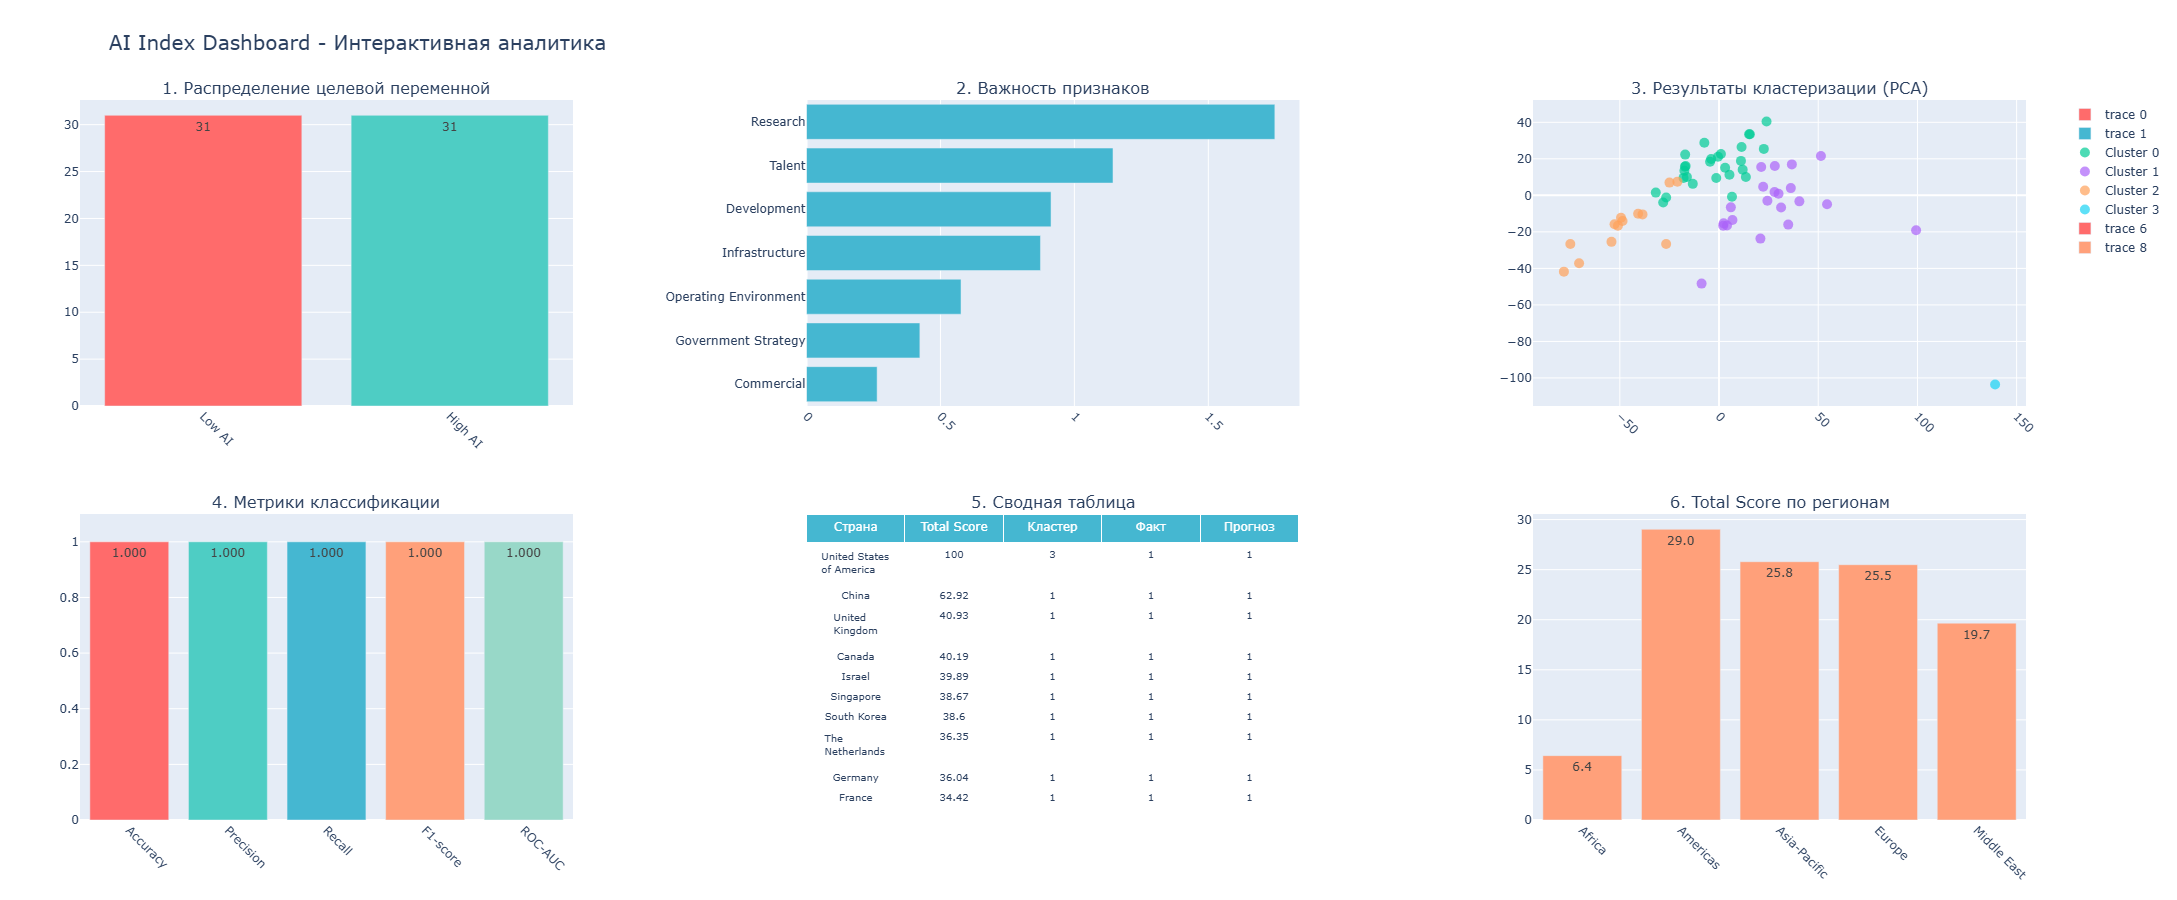

In [90]:
# 4. Отображение дашборда
print("ИНТЕРАКТИВНЫЙ ДАШБОРД")
display(region_filter, income_filter, cluster_filter, score_range)

region_filter.observe(update_dashboard, names='value')
income_filter.observe(update_dashboard, names='value')
cluster_filter.observe(update_dashboard, names='value')
score_range.observe(update_dashboard, names='value')

update_dashboard()

In [88]:
# Дополнительная статистика

print("ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА")


# Точность предсказаний
correct_predictions = (df['Target'] == df['Prediction']).sum()
accuracy_overall = correct_predictions / len(df)
print(f"Общая точность на всех данных: {accuracy_overall:.4f} ({correct_predictions}/{len(df)})")

# Распределение по кластерам
print("\nРаспределение по кластерам:")
cluster_stats = df.groupby('Cluster').agg({
    'Total score': ['mean', 'std', 'count'],
    'Target': 'mean'
}).round(2)
print(cluster_stats)

# Топ стран по вероятности
print("\nТоп-10 стран по вероятности высокого AI развития:")
top_countries = df.nlargest(10, 'Prediction_Proba')[['Country', 'Total score', 
                                                        'Prediction_Proba', 'Cluster']]
print(top_countries.to_string(index=False))

# Сохранение результатов
df.to_csv('ai_index_with_predictions.csv', index=False)
print("\nДанные с предсказаниями сохранены в 'ai_index_with_predictions.csv'")

ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА
Общая точность на всех данных: 1.0000 (62/62)

Распределение по кластерам:
        Total score             Target
               mean   std count   mean
Cluster                               
0             20.24  4.60    27   0.33
1             34.74  7.88    21   1.00
2              8.21  5.31    13   0.00
3            100.00   NaN     1   1.00

Топ-10 стран по вероятности высокого AI развития:
                 Country  Total score  Prediction_Proba  Cluster
United States of America       100.00          1.000000        3
                   China        62.92          0.999986        1
          United Kingdom        40.93          0.993048        1
                  Canada        40.19          0.992871        1
             South Korea        38.60          0.991973        1
               Singapore        38.67          0.987885        1
         The Netherlands        36.35          0.983770        1
                  Israel        39.89          0.983420

In [92]:
print("\n КЛАССИФИКАЦИЯ:")
print(f"   • Реализовано моделей: {len(models)}")
print(f"   • Лучшая модель: {best_model_name}")
print(f"   • F1-score: {results[best_model_name]['f1']:.4f}")
print(f"   • ROC-AUC: {results[best_model_name]['roc_auc']:.4f}")
print(f"   • Модель сохранена: best_classifier.joblib")


 КЛАССИФИКАЦИЯ:
   • Реализовано моделей: 3
   • Лучшая модель: Logistic Regression
   • F1-score: 1.0000
   • ROC-AUC: 1.0000
   • Модель сохранена: best_classifier.joblib
